# Formative 2: Multimodal Data Preprocessing

This notebook shows how we cleaned and merged the customer datasets, processed images and sound, and built the three-model system.

## tl;dr

The social dataset had 155 rows, including 5 exact duplicates. The transaction dataset had 150 rows and 10 missing ratings. After cleaning social profiles and doing a validated many-to-one inner join, 117 transactions remained and no transaction was duplicated.

The product model got 0.167 accuracy, 0.177 macro F1-score, and 1.746 log loss on 30 held-out rows. This is a weak result, so it should be treated as a classroom simulation and not a real shopping system.

The image and audio pipelines each produced 16 feature rows after augmentation. The image model got 1.000 accuracy, 1.000 macro F1-score, and 0.088 log loss, but only Christian had enough original images for a held-out evaluation. The audio model got 1.000 accuracy, 1.000 macro F1-score, and 0.096 log loss across Christian and Mahlet. These high authentication scores come from a very small dataset and should not be generalized.

## Context & Methods

The required flow is face recognition, product prediction, voice approval, then display the predicted product. Images are augmented using rotation, horizontal flip, and grayscale. Audio is augmented with pitch shift, time stretch, and background noise.

### Key Assumptions

- IDs such as A178 and 178 represent the same customer.
- Repeated social observations are useful, so they are aggregated to customer-level averages and maximums.
- Exact duplicate social rows are removed first.
- An inner join is used because the recommendation model needs features from both sources.
- Missing customer ratings are filled with the median for the cleaned dataset, but rating is not used to predict product because it is collected after purchase.
- All augmentations from one original sample stay in the same model split to reduce leakage.

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from scipy.signal import spectrogram
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from src.audio_pipeline import load_audio, process_audio_dataset
from src.auth_model import train_identity_model
from src.image_pipeline import process_image_dataset
from src.tabular_pipeline import (
    MODEL_FEATURES,
    RANDOM_STATE,
    TARGET,
    make_product_pipeline,
    merge_and_engineer,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## Data

### 1. Load and inspect the two tabular sources

In [2]:
social = pd.read_csv("data/raw/customer_social_profiles.csv")
transactions = pd.read_csv("data/raw/customer_transactions.csv")

print("Social shape:", social.shape)
print("Transaction shape:", transactions.shape)
display(social.head())
display(transactions.head())

Social shape: (155, 5)
Transaction shape: (150, 6)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


In [3]:
quality_table = pd.DataFrame({
    "social_dtype": social.dtypes.astype(str),
    "social_nulls": social.isna().sum(),
}).fillna("-")
transaction_quality = pd.DataFrame({
    "transaction_dtype": transactions.dtypes.astype(str),
    "transaction_nulls": transactions.isna().sum(),
})
display(quality_table)
display(transaction_quality)
print("Exact social duplicates:", social.duplicated().sum())
print("Exact transaction duplicates:", transactions.duplicated().sum())

,social_dtype,social_nulls
customer_id_new,object,0
social_media_platform,object,0
engagement_score,int64,0
purchase_interest_score,float64,0
review_sentiment,object,0


,transaction_dtype,transaction_nulls
customer_id_legacy,int64,0
transaction_id,int64,0
purchase_amount,int64,0
purchase_date,object,0
product_category,object,0
customer_rating,float64,10


Exact social duplicates: 5
Exact transaction duplicates: 0


### 2. Exploratory data analysis

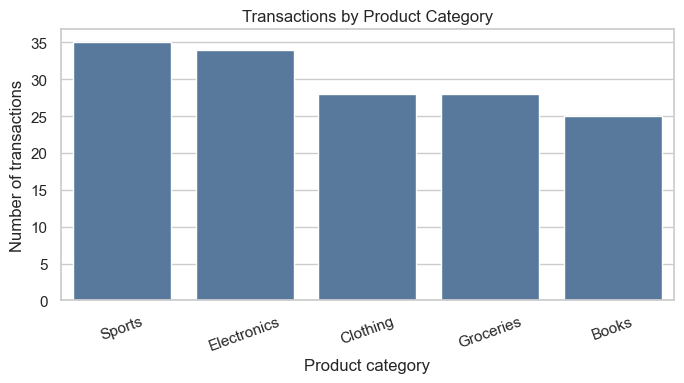

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=transactions,
    x="product_category",
    order=transactions["product_category"].value_counts().index,
    color="#4C78A8",
)
plt.title("Transactions by Product Category")
plt.xlabel("Product category")
plt.ylabel("Number of transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

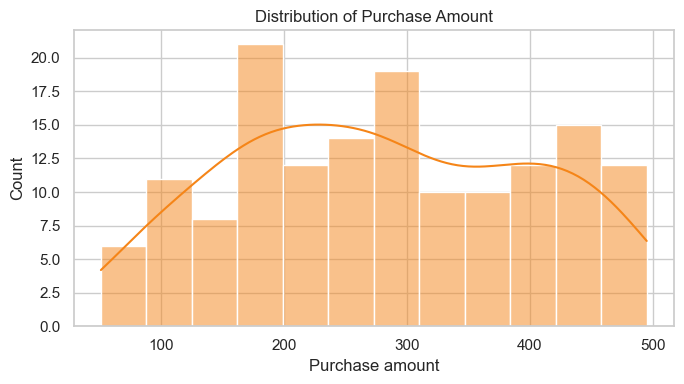

In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(transactions["purchase_amount"], bins=12, kde=True, color="#F58518")
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

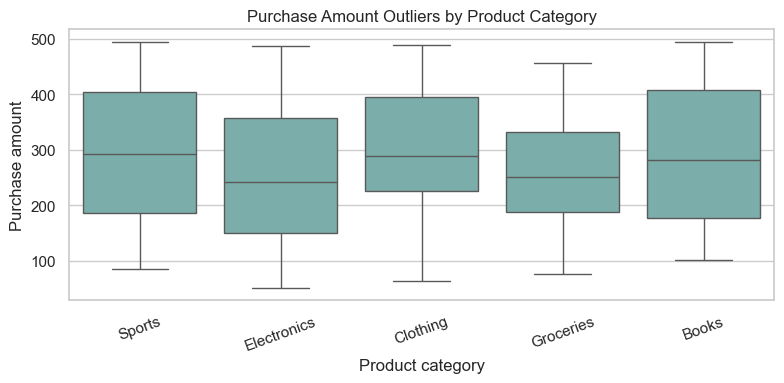

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=transactions,
    x="product_category",
    y="purchase_amount",
    color="#72B7B2",
)
plt.title("Purchase Amount Outliers by Product Category")
plt.xlabel("Product category")
plt.ylabel("Purchase amount")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

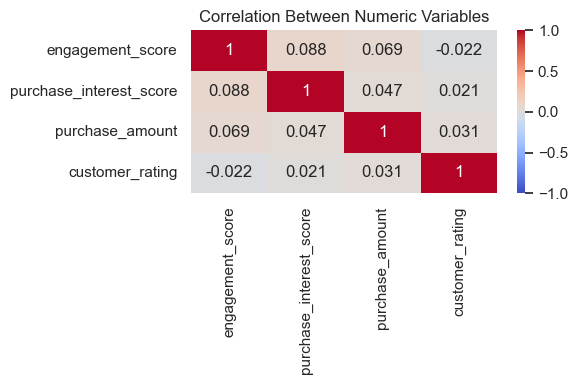

In [7]:
social_numeric = social[
    ["engagement_score", "purchase_interest_score"]
].copy()
transaction_numeric = transactions[
    ["purchase_amount", "customer_rating"]
].copy()
eda_numeric = pd.concat(
    [social_numeric.reset_index(drop=True), transaction_numeric.reset_index(drop=True)],
    axis=1,
)
plt.figure(figsize=(6, 4))
sns.heatmap(eda_numeric.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

The categories are fairly balanced, with Sports having the most rows. Purchase amounts cover almost the full range for every category, and the numeric correlations are weak. This helps explain why product prediction is difficult.

### 3. Clean, aggregate, and validate the merge

In [8]:
merged, merge_audit = merge_and_engineer(social, transactions)
display(pd.json_normalize(merge_audit, sep=".").T.rename(columns={0: "value"}))
print("Merged shape:", merged.shape)
display(merged.head())

,value
social.original_rows,155
social.exact_duplicates_removed,5
social.rows_after_deduplication,150
social.unique_customers,84
transactions.rows_after_cleaning,150
transactions.missing_ratings_imputed,10
transactions.rating_median_used,3.0
transactions.duplicate_rows_removed,0
merge.join_type,inner
merge.relationship,many_to_one


Merged shape: (117, 17)


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,engagement_score_mean,engagement_score_max,purchase_interest_score_mean,purchase_interest_score_max,social_profile_count,platform_count,review_sentiment,primary_social_platform,purchase_month,purchase_day_of_week,purchase_quarter
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,82,2.166667,3.6,3,2,Neutral,Twitter,1,0,1
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,60,4.300000,4.3,1,1,Positive,Instagram,1,1,1
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,87,4.800000,4.8,1,1,Negative,Facebook,1,2,1
3,160,1005,64,2024-01-05,Clothing,1.3,72.666667,89,2.500000,2.9,3,3,Neutral,Instagram,1,4,1
4,120,1006,395,2024-01-06,Groceries,1.1,77.000000,92,2.666667,3.6,3,2,Positive,Instagram,1,5,1


In [9]:
print("Null values after merge:")
display(merged.isna().sum().to_frame("null_count"))
print("Duplicate transaction IDs:", merged["transaction_id"].duplicated().sum())
print("Product distribution after merge:")
display(merged[TARGET].value_counts().to_frame("rows"))

Null values after merge:


,null_count
customer_id,0
transaction_id,0
purchase_amount,0
purchase_date,0
product_category,0
customer_rating,0
engagement_score_mean,0
engagement_score_max,0
purchase_interest_score_mean,0
purchase_interest_score_max,0


Duplicate transaction IDs: 0
Product distribution after merge:


,rows
product_category,
Sports,28
Electronics,27
Clothing,22
Groceries,20
Books,20


## Results

### 4. Product recommendation model

In [10]:
x = merged[MODEL_FEATURES]
y = merged[TARGET]
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
product_model = make_product_pipeline()
product_model.fit(x_train, y_train)
product_predictions = product_model.predict(x_test)
product_probabilities = product_model.predict_proba(x_test)

from sklearn.metrics import accuracy_score, f1_score, log_loss

product_metrics = {
    "accuracy": accuracy_score(y_test, product_predictions),
    "macro_f1": f1_score(y_test, product_predictions, average="macro"),
    "log_loss": log_loss(
        y_test,
        product_probabilities,
        labels=product_model.named_steps["classifier"].classes_,
    ),
}
display(pd.Series(product_metrics).round(4).to_frame("score"))

,score
accuracy,0.1667
macro_f1,0.1774
log_loss,1.7457


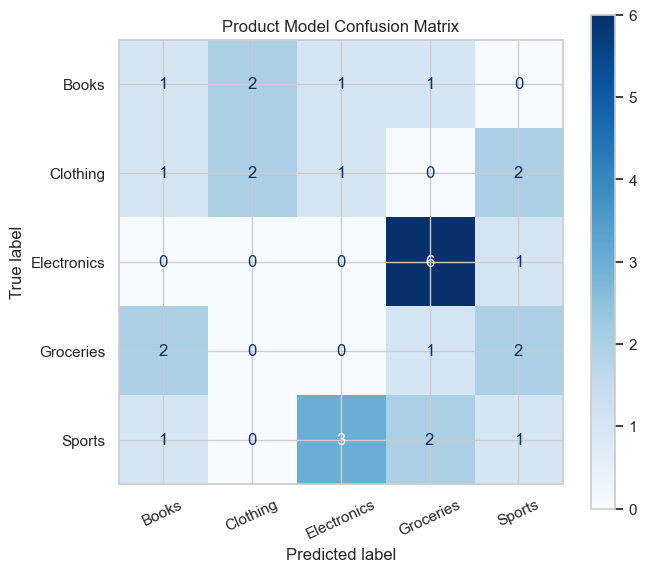

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    product_predictions,
    cmap="Blues",
    xticks_rotation=25,
    ax=ax,
)
plt.title("Product Model Confusion Matrix")
plt.tight_layout()
plt.show()

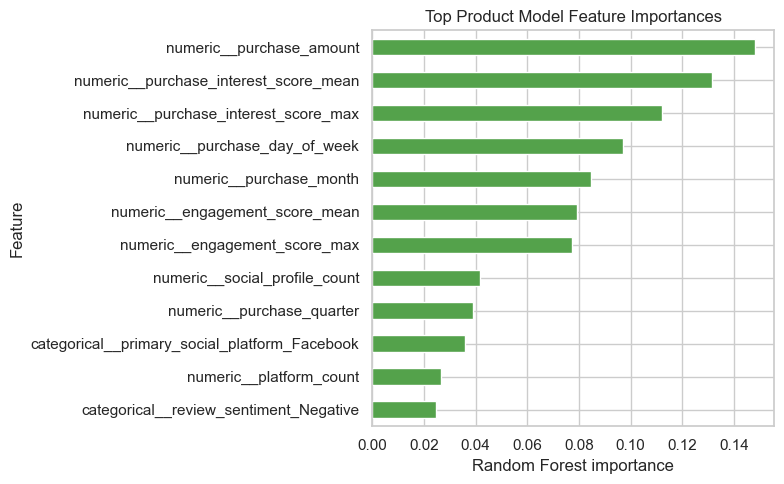

In [12]:
preprocessor = product_model.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()
importance = pd.Series(
    product_model.named_steps["classifier"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh", color="#54A24B")
plt.title("Top Product Model Feature Importances")
plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The product model does not separate the five classes well. Its accuracy is below the majority-class baseline in this split. The data appears generated for practicing preprocessing, so a low score is not surprising. More customer history and a real preference signal would be needed to improve it.

### 5. Image samples, augmentation, and features

Original images found: 4


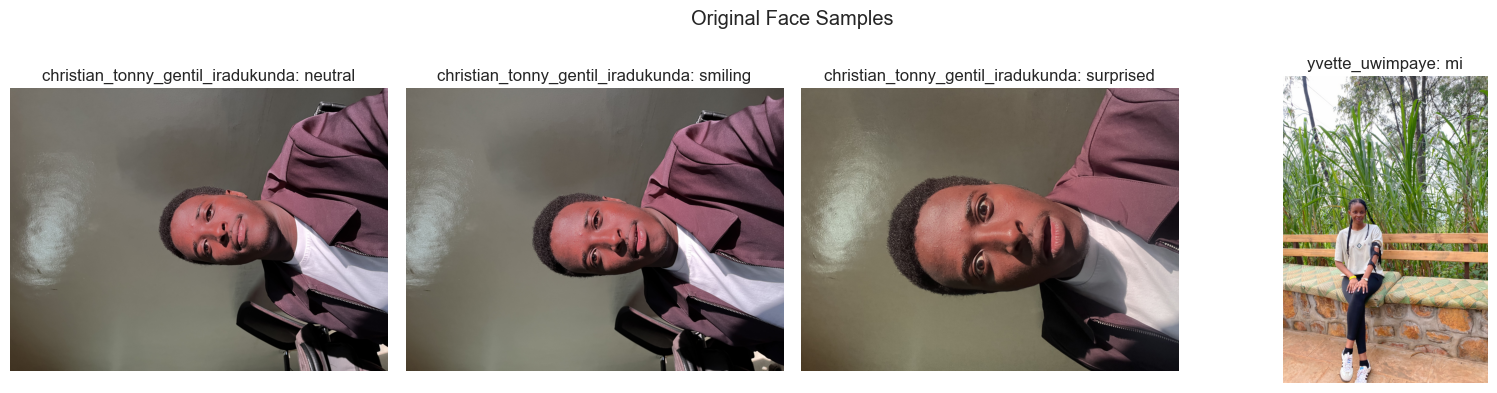

In [13]:
image_paths = sorted(
    path
    for path in Path("data/images").glob("*/*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    and "augmented" not in path.parts
)
print("Original images found:", len(image_paths))

if image_paths:
    fig, axes = plt.subplots(1, len(image_paths), figsize=(4 * len(image_paths), 4))
    axes = np.atleast_1d(axes)
    for ax, path in zip(axes, image_paths):
        with Image.open(path) as image:
            ax.imshow(image)
        ax.set_title(f"{path.parent.name}: {path.stem}")
        ax.axis("off")
    plt.suptitle("Original Face Samples")
    plt.tight_layout()
    plt.show()
else:
    print("No image samples are available yet.")

In [14]:
image_features = process_image_dataset()
if image_features.empty:
    print("Image feature extraction is waiting for group files.")
else:
    image_summary = (
        image_features.groupby(["member", "variant"])
        .size()
        .rename("rows")
        .reset_index()
    )
    display(image_summary)
    display(image_features.iloc[:4, :12])
    print("Image feature file shape:", image_features.shape)

,member,variant,rows
0,christian_tonny_gentil_iradukunda,grayscale,3
1,christian_tonny_gentil_iradukunda,horizontal_flip,3
2,christian_tonny_gentil_iradukunda,original,3
3,christian_tonny_gentil_iradukunda,rotated_15deg,3
4,yvette_uwimpaye,grayscale,1
5,yvette_uwimpaye,horizontal_flip,1
6,yvette_uwimpaye,original,1
7,yvette_uwimpaye,rotated_15deg,1


,member,source_file,variant,processed_file,red_hist_00,red_hist_01,red_hist_02,red_hist_03,red_hist_04,red_hist_05,red_hist_06,red_hist_07
0,christian_tonny_gentil_iradukunda,data/images/christian_tonny_gentil_iradukunda/...,original,data/images/augmented/christian_tonny_gentil_i...,0.044250,0.024109,0.015930,0.020142,0.020081,0.126038,0.150146,0.386780
1,christian_tonny_gentil_iradukunda,data/images/christian_tonny_gentil_iradukunda/...,rotated_15deg,data/images/augmented/christian_tonny_gentil_i...,0.085083,0.024719,0.016724,0.023438,0.021851,0.112793,0.147583,0.361267
2,christian_tonny_gentil_iradukunda,data/images/christian_tonny_gentil_iradukunda/...,horizontal_flip,data/images/augmented/christian_tonny_gentil_i...,0.044250,0.024109,0.015930,0.020142,0.020081,0.126038,0.150146,0.386780
3,christian_tonny_gentil_iradukunda,data/images/christian_tonny_gentil_iradukunda/...,grayscale,data/images/augmented/christian_tonny_gentil_i...,0.049500,0.027100,0.018799,0.027527,0.028809,0.167297,0.159912,0.408630


Image feature file shape: (16, 326)


The image CSV contains RGB and grayscale histograms, brightness statistics, and a small 16 by 16 pixel embedding. Every original gets three augmented copies.

### 6. Audio waveforms, spectrograms, augmentation, and features

Original audio files found: 4


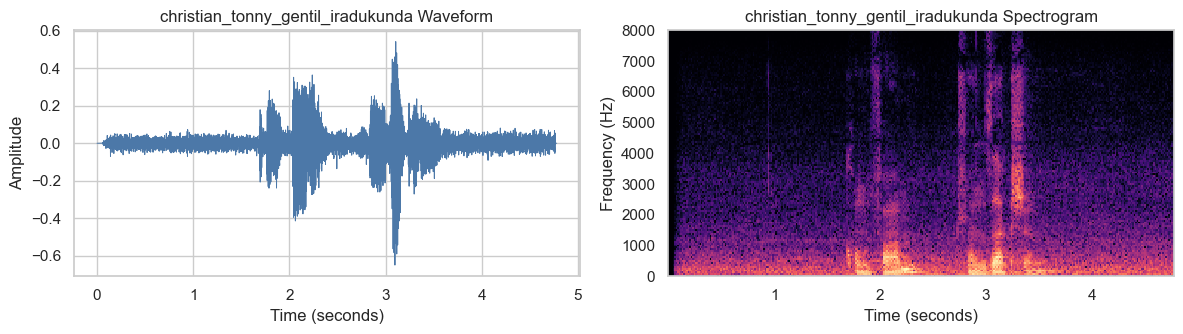

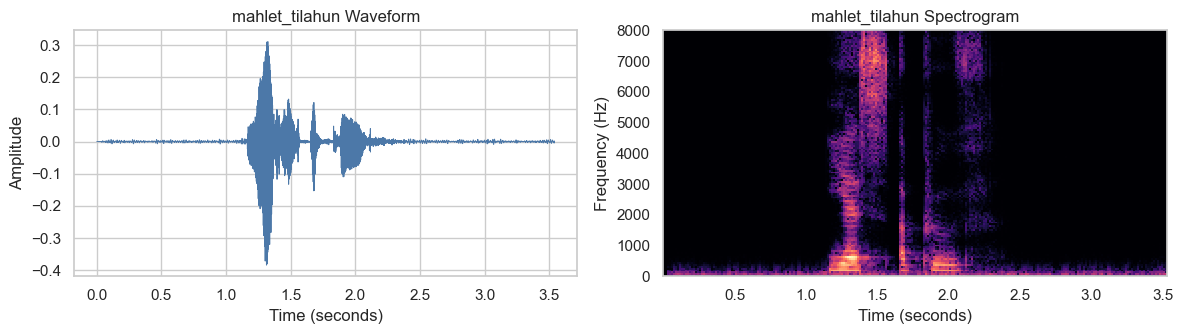

In [15]:
audio_paths = sorted(
    path
    for path in Path("data/audio").glob("*/*")
    if path.suffix.lower() in {".wav", ".m4a", ".mp3", ".aac", ".flac", ".ogg"}
    and "augmented" not in path.parts
)
print("Original audio files found:", len(audio_paths))

for member in sorted({path.parent.name for path in audio_paths}):
    path = next(path for path in audio_paths if path.parent.name == member)
    audio, sample_rate = load_audio(path)
    times = np.arange(len(audio)) / sample_rate
    frequencies, spec_times, power = spectrogram(audio, fs=sample_rate)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(times, audio, color="#4C78A8", linewidth=0.7)
    axes[0].set_title(f"{member} Waveform")
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel("Amplitude")
    axes[1].pcolormesh(
        spec_times,
        frequencies,
        10 * np.log10(power + 1e-10),
        shading="auto",
        cmap="magma",
    )
    axes[1].set_ylim(0, 8000)
    axes[1].set_title(f"{member} Spectrogram")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

In [16]:
audio_features = process_audio_dataset()
if audio_features.empty:
    print("Audio feature extraction is waiting for group files.")
else:
    audio_summary = (
        audio_features.groupby(["member", "variant"])
        .size()
        .rename("rows")
        .reset_index()
    )
    display(audio_summary)
    display(audio_features.iloc[:4, :12])
    print("Audio feature file shape:", audio_features.shape)

,member,variant,rows
0,christian_tonny_gentil_iradukunda,background_noise,2
1,christian_tonny_gentil_iradukunda,original,2
2,christian_tonny_gentil_iradukunda,pitch_shift_2,2
3,christian_tonny_gentil_iradukunda,time_stretch_0_90,2
4,mahlet_tilahun,background_noise,2
5,mahlet_tilahun,original,2
6,mahlet_tilahun,pitch_shift_2,2
7,mahlet_tilahun,time_stretch_0_90,2


,member,source_file,variant,processed_file,mfcc_01_mean,mfcc_01_std,mfcc_02_mean,mfcc_02_std,mfcc_03_mean,mfcc_03_std,mfcc_04_mean,mfcc_04_std
0,christian_tonny_gentil_iradukunda,data/audio/christian_tonny_gentil_iradukunda/c...,original,data/audio/augmented/christian_tonny_gentil_ir...,-50.411088,11.146664,1.451774,3.149804,-1.364160,1.387654,0.812959,1.188300
1,christian_tonny_gentil_iradukunda,data/audio/christian_tonny_gentil_iradukunda/c...,pitch_shift_2,data/audio/augmented/christian_tonny_gentil_ir...,-49.164950,10.425205,0.782216,3.154700,-1.194752,1.399501,0.249072,1.223107
2,christian_tonny_gentil_iradukunda,data/audio/christian_tonny_gentil_iradukunda/c...,time_stretch_0_90,data/audio/augmented/christian_tonny_gentil_ir...,-51.869677,10.810395,2.510523,3.312807,-1.981467,1.536153,1.669840,1.294955
3,christian_tonny_gentil_iradukunda,data/audio/christian_tonny_gentil_iradukunda/c...,background_noise,data/audio/augmented/christian_tonny_gentil_ir...,-48.506164,5.769895,-0.204080,3.288354,-0.251243,1.283557,0.009700,1.261015


Audio feature file shape: (16, 34)


The audio CSV saves 13 MFCC means, 13 MFCC standard deviations, spectral roll-off, RMS energy, zero-crossing rate, and duration. The Christian and Mahlet recordings have visible speech bursts, and most energy is concentrated in lower frequencies.

### 7. Facial recognition and voiceprint models

In [17]:
auth_results = {}
for kind, features in {"image": image_features, "audio": audio_features}.items():
    metadata_columns = {"member", "source_file", "variant", "processed_file"}
    feature_columns = [
        column for column in features.columns if column not in metadata_columns
    ]
    _, metrics = train_identity_model(
        features,
        feature_columns,
        Path(f"models/{kind}_recognition_model.joblib"),
        Path(f"data/processed/{kind}_model_metrics.json"),
    )
    auth_results[kind] = metrics

auth_summary = pd.DataFrame(
    {
        kind: {
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["f1_macro"],
            "log_loss": metrics["log_loss"],
            "trained_identities": len(metrics["trained_identities"]),
            "evaluated_identities": len(metrics["evaluated_identities"]),
        }
        for kind, metrics in auth_results.items()
    }
).T
display(auth_summary.round(4))
print("Image identity coverage:", auth_results["image"]["original_samples_per_identity"])
print("Audio identity coverage:", auth_results["audio"]["original_samples_per_identity"])

,accuracy,macro_f1,log_loss,trained_identities,evaluated_identities
image,1.0,1.0,0.0880,2.0,1.0
audio,1.0,1.0,0.0959,2.0,2.0


Image identity coverage: {'christian_tonny_gentil_iradukunda': 3, 'yvette_uwimpaye': 1}
Audio identity coverage: {'christian_tonny_gentil_iradukunda': 2, 'mahlet_tilahun': 2}


Both authentication models worked on the held-out original samples. The audio evaluation covers both available speakers. The image evaluation only covers Christian because Yvette supplied one original image, so the perfect image score must be read with that limitation. Augmented copies from one original were never split across training and testing.

## Takeaways

- Cleaning and aggregation prevented a many-to-many merge from duplicating transactions.
- The product model is functional, but its current test performance is weak and should not be presented as production quality.
- The image and audio processors create the required augmentations and feature CSV files, and both authentication models run successfully.
- The valid CLI transaction approved Christian and predicted Clothing. A non-face image was rejected at the face step, and a Yvette-face/Mahlet-voice combination was denied because the identities did not match.
- The shared folder is still missing Hassan's media, Mahlet's images, and most of Yvette's media. The GitHub and demonstration-video links must also be inserted before submission.